In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow import keras
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Colab Notebooks/diabetes.csv'
df = pd.read_csv(path)

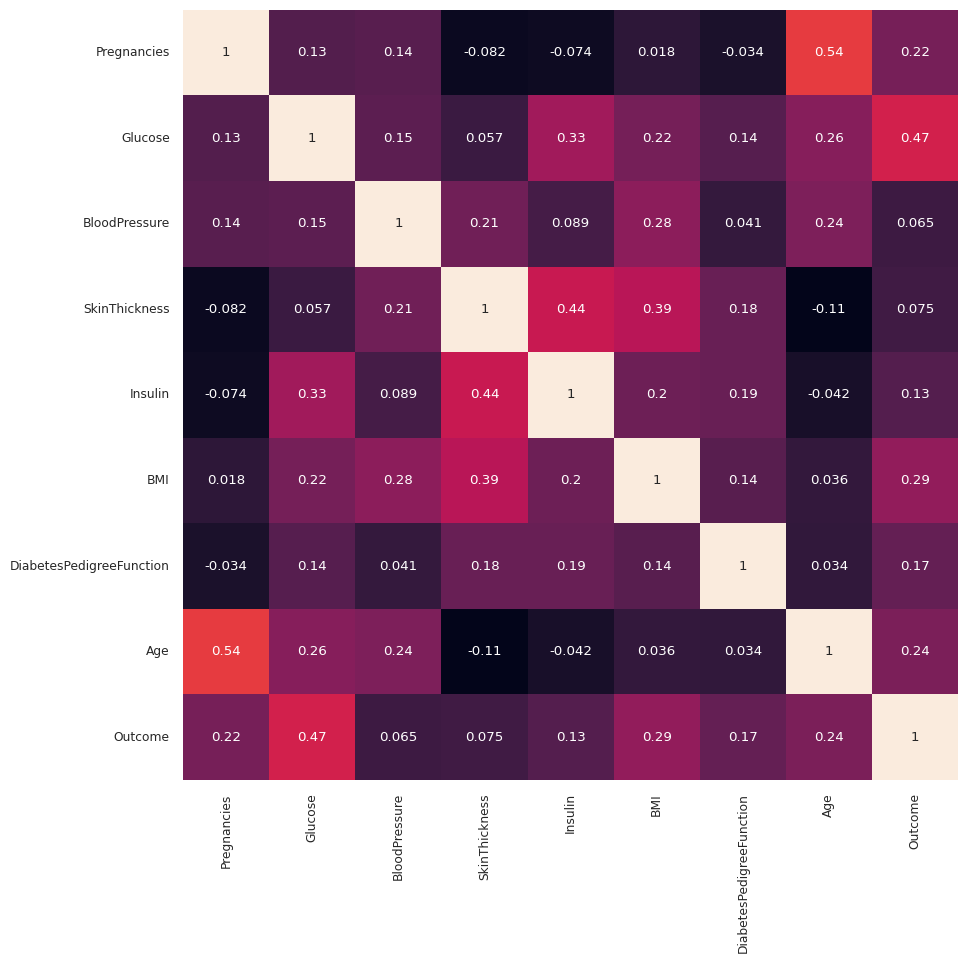

In [2]:
df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X=df.drop('BMI',axis=1)
X.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,0.627,50,1
1,1,85,66,29,0,0.351,31,0
2,8,183,64,0,0,0.672,32,1
3,1,89,66,23,94,0.167,21,0
4,0,137,40,35,168,2.288,33,1


In [4]:
y = df['BMI']
Y = y.values

In [5]:
X = df.drop('BMI', axis=1)
X = X.values
print(X.shape)

(768, 8)


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# 1. fit_transform: 훈련 데이터의 평균과 표준편차를 '계산(fit)'하고 바로 '변환(transform)'합니다. 모든 데이터를 평균을 0 표준편차는 1로 변신
X_train = scaler.fit_transform(X_train)

# 2. transform: 중요! 훈련 데이터에서 구한 '그 기준 그대로' 테스트 데이터도 변환합니다.
# (테스트 데이터로 새로 계산하면 안 돼요. 시험 문제는 공부한 기준대로 풀어야 하니까요!)
X_test = scaler.transform(X_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((614, 8), (614,), (154, 8), (154,))

In [9]:
#Defining the model

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

#입력 컬럼이 15갱임
model.add(Dense(8,input_shape=(8,),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))
#결과가 1개이므로 마지막은 1로 끝남

model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,303 (5.09 KB)

 Trainable params: 1,303 (5.09 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
N_EPOCHS = 30

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 1070.6635 - mse: 1070.6635 - val_loss: 978.1843 - val_mse: 978.1843
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1020.5204 - mse: 1020.5204 - val_loss: 924.5057 - val_mse: 924.5057
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 951.7267 - mse: 951.7267 - val_loss: 846.9003 - val_mse: 846.9003
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 853.7011 - mse: 853.7011 - val_loss: 741.8394 - val_mse: 741.8394
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 724.2955 - mse: 724.2955 - val_loss: 606.1703 - val_mse: 606.1703
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 568.9893 - mse: 568.9893 - val_loss: 456.2592 - val_mse: 456.2592
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 406.2939 - mse: 406.2939 - val_loss: 309.4040 - val_mse: 309.4040
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 260.3128 - mse: 260.3128 - val_loss: 196.7266 - val_mse: 196.7

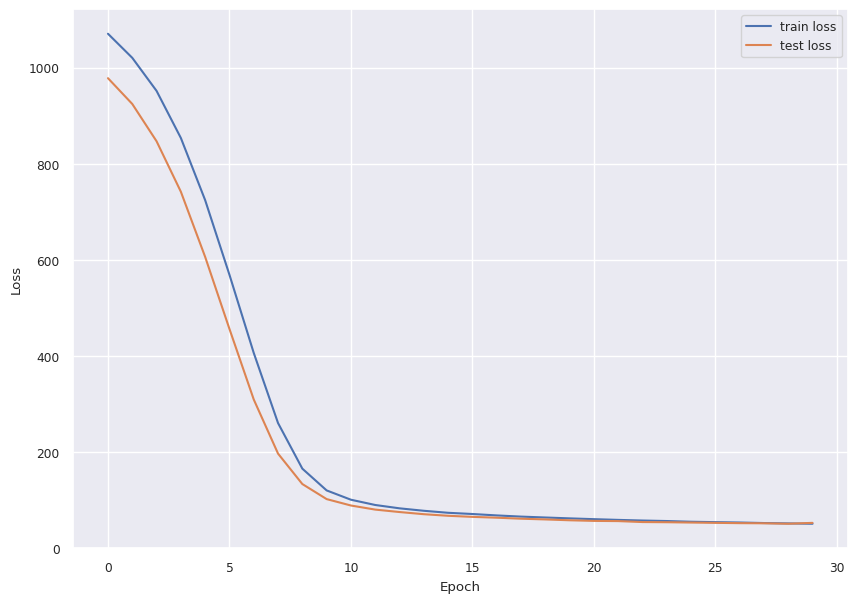

In [11]:
# loss 체크
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 52.5732 - mse: 52.5732 


[52.573158264160156, 52.573158264160156]